# SDR Linkbudget (Solution)

Ziel:
- Traeger um 433 MHz messen
- Empfangsleistung mit Kalibrierung aus `../03_02_LABOR-2/calibration.json` bestimmen
- bei 0 dBi Sende-/Empfangsantenne: C/N0 und effektive Rauschtemperatur ableiten
- Freiraumdaempfung (LOS) berechnen und mit Messwert vergleichen (Multipath-Indiz)

In [ ]:
import os
import json
import math
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

LAB_DIR = Path.cwd()
CAL_PATH = LAB_DIR.parent / "03_02_LABOR-2" / "calibration.json"

# RTL-SDR DLL-Ordner suchen (analog zu rtl_sdr_sliders.ipynb)
_driver_dir = None
for p in [Path.cwd()] + list(Path.cwd().parents):
    candidate = p / "rtl-sdr-driver"
    if candidate.exists() and (candidate / "librtlsdr.dll").exists():
        _driver_dir = candidate
        break
if _driver_dir is not None:
    _path = str(_driver_dir)
    os.environ["PATH"] = _path + os.pathsep + os.environ.get("PATH", "")
    if hasattr(os, "add_dll_directory"):
        os.add_dll_directory(_path)
    print("RTL-SDR Treiber gefunden:", _driver_dir)
else:
    print("Hinweis: rtl-sdr-driver (librtlsdr.dll) nicht gefunden.")

CENTER_FREQ_HZ = 133.92e6
SAMPLE_RATE_HZ = 2.048e6
GAIN_DB = 20
N = 4096
M = 32

# Bekannt gegebene Sendeleistung (anpassen falls noetig)
TX_POWER_DBM = -10.0 # tx power in dBm

# Geschaetzter LOS-Abstand (fuer Vergleich mit gemessener Linkdaempfung)
DIST_GUESS_M = 5.0 # distance in meter

print("Calibration file:", CAL_PATH)

RTL-SDR Treiber gefunden: C:\_Git\KT-workspace\rtl-sdr-driver
Calibration file: C:\_Git\KT-workspace\lab_suite\labs\03_02_LABOR-2\calibration.json


In [31]:
def load_calibration(path: Path) -> dict:
    data = json.loads(path.read_text(encoding="utf-8"))
    return data

def get_cal_offset_db(cal: dict, gain_db: float) -> float:
    gains = cal.get("gains", [])
    if not gains:
        raise ValueError("No gains in calibration file")
    best = min(gains, key=lambda g: abs(float(g["gain_dB"]) - float(gain_db)))
    return float(best["calibration_offset_dB"])

def capture_iq_or_fallback(center_hz: float, fs_hz: float, gain_db: float, total_samples: int) -> np.ndarray:
    try:
        from rtlsdr import RtlSdr
        sdr = RtlSdr()
        sdr.sample_rate = fs_hz
        sdr.center_freq = center_hz
        sdr.gain = gain_db
        iq = sdr.read_samples(total_samples)
        sdr.close()
        return np.asarray(iq, dtype=np.complex64)
    except Exception as ex:
        print("RTL-SDR nicht verfuegbar, nutze synthetischen Fallback:", ex)
        t = np.arange(total_samples, dtype=np.float64) / fs_hz
        tone_off_hz = 70e3
        tone = 0.08 * np.exp(1j * 2 * np.pi * tone_off_hz * t)
        noise = (np.random.randn(total_samples) + 1j * np.random.randn(total_samples)) * 0.01
        return (tone + noise).astype(np.complex64)

def avg_spectrum(iq: np.ndarray, fs_hz: float, nfft: int, m_avg: int):
    need = nfft * m_avg
    if iq.size < need:
        raise ValueError(f"Need {need} samples, got {iq.size}")
    x = iq[:need].reshape(m_avg, nfft)
    win = np.hanning(nfft).astype(np.float64)
    spec = np.fft.fftshift(np.fft.fft(x * win, axis=1), axes=1)
    mag = np.mean(np.abs(spec), axis=0)
    mag_db = 20.0 * np.log10(np.maximum(mag, 1e-15))
    f_rel = np.fft.fftshift(np.fft.fftfreq(nfft, d=1.0 / fs_hz))
    return f_rel, mag_db

def estimate_noise_db(mag_db: np.ndarray, peak_idx: int, guard: int = 4) -> float:
    mask = np.ones_like(mag_db, dtype=bool)
    lo = max(0, peak_idx - guard)
    hi = min(mag_db.size, peak_idx + guard + 1)
    mask[lo:hi] = False
    return float(np.median(mag_db[mask]))

In [32]:
cal = load_calibration(CAL_PATH)
cal_offset_db = get_cal_offset_db(cal, GAIN_DB)

iq = capture_iq_or_fallback(CENTER_FREQ_HZ, SAMPLE_RATE_HZ, GAIN_DB, N * M)
f_rel_hz, mag_db_raw = avg_spectrum(iq, SAMPLE_RATE_HZ, N, M)

peak_idx = int(np.argmax(mag_db_raw))
carrier_off_hz = float(f_rel_hz[peak_idx])
carrier_freq_hz = CENTER_FREQ_HZ + carrier_off_hz

rx_power_dbm = float(mag_db_raw[peak_idx] + cal_offset_db)
noise_bin_dbm = estimate_noise_db(mag_db_raw, peak_idx, guard=4) + cal_offset_db

bin_bw_hz = SAMPLE_RATE_HZ / N
n0_dbm_hz = noise_bin_dbm - 10.0 * math.log10(bin_bw_hz)
cn0_db_hz = rx_power_dbm - n0_dbm_hz

# N0 = k*T => Referenz -174 dBm/Hz bei 290 K
t_eff_k = 290.0 * 10.0 ** ((n0_dbm_hz + 174.0) / 10.0)

c0 = 299_792_458.0
wavelength_m = c0 / carrier_freq_hz

fspl_meas_db = TX_POWER_DBM - rx_power_dbm
d_from_meas_m = (10.0 ** (fspl_meas_db / 20.0)) * wavelength_m / (4.0 * math.pi)

fspl_guess_db = 20.0 * math.log10(4.0 * math.pi * DIST_GUESS_M / wavelength_m)
multipath_delta_db = fspl_meas_db - fspl_guess_db

print(f"Carrier freq      : {carrier_freq_hz/1e6:.6f} MHz")
print(f"RX power          : {rx_power_dbm:.2f} dBm")
print(f"Noise density N0  : {n0_dbm_hz:.2f} dBm/Hz")
print(f"C/N0              : {cn0_db_hz:.2f} dB-Hz")
print(f"T_eff             : {t_eff_k:.1f} K")
print(f"Wavelength        : {wavelength_m:.4f} m")
print(f"FSPL (measured)   : {fspl_meas_db:.2f} dB")
print(f"Distance from FSPL: {d_from_meas_m:.1f} m")
print(f"FSPL (guess LOS)  : {fspl_guess_db:.2f} dB @ d={DIST_GUESS_M:.1f} m")
print(f"Delta (meas-guess): {multipath_delta_db:+.2f} dB")

Carrier freq      : 133.000000 MHz
RX power          : -51.94 dBm
Noise density N0  : -154.16 dBm/Hz
C/N0              : 102.22 dB-Hz
T_eff             : 27978.4 K
Wavelength        : 2.2541 m
FSPL (measured)   : 41.94 dB
Distance from FSPL: 22.4 m
FSPL (guess LOS)  : 28.90 dB @ d=5.0 m
Delta (meas-guess): +13.03 dB


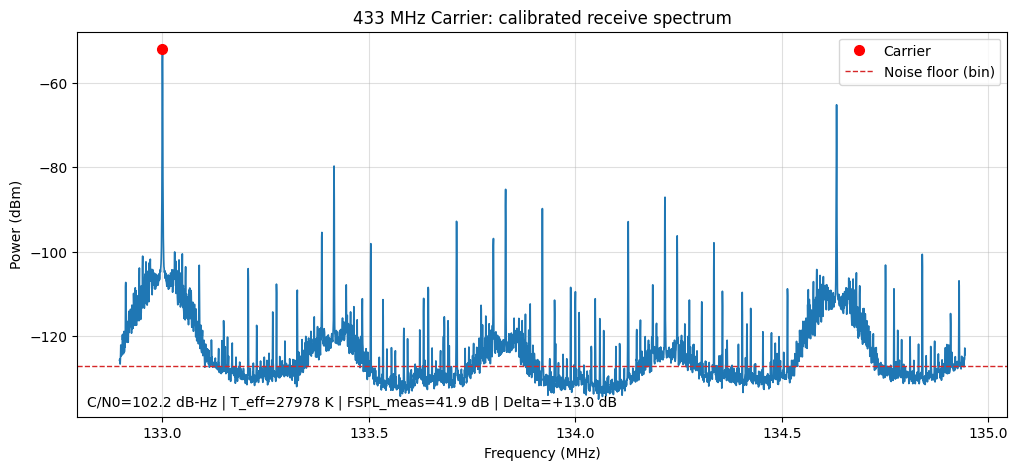

In [33]:
fig, ax = plt.subplots(figsize=(12, 5))
f_mhz = (CENTER_FREQ_HZ + f_rel_hz) / 1e6
ax.plot(f_mhz, mag_db_raw + cal_offset_db, lw=1.2, color="C0")
ax.plot([carrier_freq_hz/1e6], [rx_power_dbm], "o", color="red", ms=7, label="Carrier")
ax.axhline(noise_bin_dbm, color="C3", ls="--", lw=1.0, label="Noise floor (bin)")
ax.set_title("433 MHz Carrier: calibrated receive spectrum")
ax.set_xlabel("Frequency (MHz)")
ax.set_ylabel("Power (dBm)")
ax.grid(True, alpha=0.4)
ax.legend(loc="best")
ax.text(
    0.01, 0.02,
    f"C/N0={cn0_db_hz:.1f} dB-Hz | T_eff={t_eff_k:.0f} K | FSPL_meas={fspl_meas_db:.1f} dB | Delta={multipath_delta_db:+.1f} dB",
    transform=ax.transAxes,
    ha="left", va="bottom", fontsize=10,
)
plt.show()